#  Treinamento (DQN com Experience Replay)


In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path('..').resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import matplotlib.pyplot as plt

# Importando as classes do nosso projeto
from src.sor_env import MultiVenueSOREnv
from src.moe_dqn import MoENetwork
from src.train_agent import train_dqn

# Configuração visual para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
import os
import random
import numpy as np
import torch

def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

def assert_env_info_keys(info: dict) -> None:
    required = {
        "inventory_left", "arrival_price",
        "executed_cost", "executed_volume",
        "avg_price", "slippage", "is_valid", "rejection_reason",
        "t", "T",
    }
    missing = required - set(info.keys())
    if missing:
        raise RuntimeError(f"Env.step() não está retornando info auditável. Faltam: {missing}")

### Gerando dados simulados (100 steps) para o treinamento

In [3]:
steps = 100
np.random.seed(42) # Semente fixa para reprodutibilidade

df_b3 = pd.DataFrame({
    'ask_1': np.random.uniform(35.00, 35.10, steps), 'vol_ask_1': np.random.randint(100, 1000, steps),
    'ask_2': np.random.uniform(35.11, 35.20, steps), 'vol_ask_2': np.random.randint(100, 1000, steps),
    'ask_3': np.random.uniform(35.21, 35.30, steps), 'vol_ask_3': np.random.randint(100, 1000, steps),
    'ask_4': np.random.uniform(35.31, 35.40, steps), 'vol_ask_4': np.random.randint(100, 1000, steps),
    'ask_5': np.random.uniform(35.41, 35.50, steps), 'vol_ask_5': np.random.randint(100, 1000, steps),
})

df_base = pd.DataFrame({
    'ask_1': np.random.uniform(34.98, 35.08, steps), 'vol_ask_1': np.random.randint(50, 800, steps),
    'ask_2': np.random.uniform(35.09, 35.18, steps), 'vol_ask_2': np.random.randint(50, 800, steps),
    'ask_3': np.random.uniform(35.19, 35.28, steps), 'vol_ask_3': np.random.randint(50, 800, steps),
    'ask_4': np.random.uniform(35.29, 35.38, steps), 'vol_ask_4': np.random.randint(50, 800, steps),
    'ask_5': np.random.uniform(35.39, 35.48, steps), 'vol_ask_5': np.random.randint(50, 800, steps),
})

print(f"Dados de treinamento gerados: {len(df_b3)} steps (milissegundos) de profundidade LOB.")

Dados de treinamento gerados: 100 steps (milissegundos) de profundidade LOB.


In [4]:
# 1. Instanciando o Ambiente (Ordem de 5.000 ações)
env = MultiVenueSOREnv(lob_b3=df_b3, lob_base=df_base, total_inventory=5000)

# 2. Instanciando a Rede Neural (Cérebro MoE)
agente_moe = MoENetwork(input_dim=5, output_dim=4, num_experts=3)

# 3. Executando o Loop de Treinamento
print("Iniciando o treinamento via Experience Replay. Isso pode levar alguns segundos...")

# A função train_dqn vai rodar os episódios e retornar o modelo atualizado e o histórico
modelo_treinado, historico_recompensas = train_dqn(env, agente_moe)

print("\nTreinamento finalizado com sucesso!")

Iniciando o treinamento via Experience Replay. Isso pode levar alguns segundos...

Treinamento finalizado com sucesso!


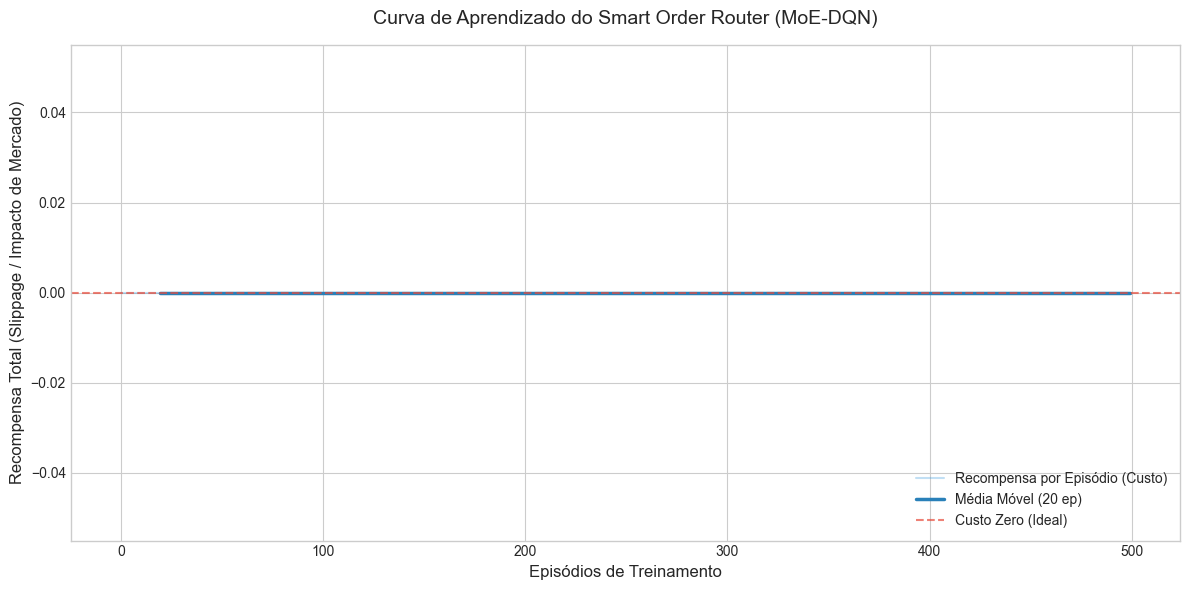

In [5]:
def plot_learning_curve(recompensas, window_size=20):
    plt.figure(figsize=(12, 6))

    # Recompensas brutas (linha clara)
    plt.plot(recompensas, color='#3498db', alpha=0.3, label='Recompensa por Episódio (Custo)')

    # Média Móvel (linha escura)
    if len(recompensas) >= window_size:
        moving_avg = np.convolve(recompensas, np.ones(window_size)/window_size, mode='valid')
        plt.plot(range(window_size-1, len(recompensas)), moving_avg, 
                 color='#2980b9', linewidth=2.5, label=f'Média Móvel ({window_size} ep)')

    plt.title('Curva de Aprendizado do Smart Order Router (MoE-DQN)', fontsize=14, pad=15)
    plt.xlabel('Episódios de Treinamento', fontsize=12)
    plt.ylabel('Recompensa Total (Slippage / Impacto de Mercado)', fontsize=12)

    # Linha de base (Custo Zero)
    plt.axhline(y=0, color='#e74c3c', linestyle='--', alpha=0.7, label='Custo Zero (Ideal)')

    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Gerando o gráfico com os dados do treinamento
plot_learning_curve(historico_recompensas)

In [6]:
# Criando a pasta 'models' caso ela não exista
caminho_modelo = ROOT_DIR / 'models' / 'moe_dqn_sor.pth'
caminho_modelo.parent.mkdir(parents=True, exist_ok=True)

# Salvando o estado do dicionário da rede neural
torch.save(modelo_treinado.state_dict(), caminho_modelo)

print(f"Pesos da rede neural salvos com sucesso em:\n{caminho_modelo}")
print("Agora você pode carregar este arquivo no script de avaliação (evaluate_baselines.py)!")

Pesos da rede neural salvos com sucesso em:
/Users/tuerepinto/Documents/repository/tcc-sor-dql-moe/models/moe_dqn_sor.pth
Agora você pode carregar este arquivo no script de avaliação (evaluate_baselines.py)!
